In [33]:

import pandas as pd

btc = pd.read_csv("/Users/lizeyu/Desktop/qoc/tmp/raw/5m_klines_raw/BTCUSDT_klines_5m.csv")



In [35]:
# Update Close Time and Open Time columns if values are less than 2000000000000
btc['Close Time'] = btc['Close Time'].apply(lambda x: x * 1000 if x < 2000000000000 else x)
btc['Open Time'] = btc['Open Time'].apply(lambda x: x * 1000 if x < 2000000000000 else x)

In [36]:

# 将时间戳转换为 datetime 格式
btc['Close Time'] = pd.to_datetime(btc['Close Time'], unit='us')
btc['Open Time'] = pd.to_datetime(btc['Open Time'], unit='us')

# 设置索引
btc.set_index("Close Time", inplace=True)

In [37]:
btc

,index,Open Time,Open,High,Low,Close,Volume,Quote Asset Volume,Number of Trades,Taker Buy Base Volume,Taker Buy Quote Volume,Ignore
Close Time,,,,,,,,,,,,
2024-01-01 00:04:59.999000,0,2024-01-01 00:00:00,42283.58,42397.23,42261.02,42397.23,155.25731,6.572926e+06,6350,106.05732,4.490262e+06,0
2024-01-01 00:09:59.999000,1,2024-01-01 00:05:00,42397.22,42432.74,42385.26,42409.96,141.31102,5.993375e+06,5134,69.45156,2.945452e+06,0
2024-01-01 00:14:59.999000,2,2024-01-01 00:10:00,42409.97,42488.09,42409.96,42488.00,135.14249,5.738386e+06,5167,73.25966,3.110338e+06,0
2024-01-01 00:19:59.999000,3,2024-01-01 00:15:00,42488.00,42554.57,42458.58,42458.85,163.32541,6.943230e+06,6153,82.81591,3.520689e+06,0
2024-01-01 00:24:59.999000,4,2024-01-01 00:20:00,42458.85,42491.10,42445.84,42473.93,117.27112,4.979136e+06,3094,49.06278,2.083183e+06,0
...,...,...,...,...,...,...,...,...,...,...,...,...
2025-08-31 23:39:59.999999,175387,2025-08-31 23:35:00,108251.22,108416.35,108111.00,108156.01,113.69077,1.230942e+07,16780,65.43264,7.086852e+06,0
2025-08-31 23:44:59.999999,175388,2025-08-31 23:40:00,108156.00,108258.00,108076.93,108258.00,102.71622,1.110862e+07,13502,56.70324,6.131969e+06,0
2025-08-31 23:49:59.999999,175389,2025-08-31 23:45:00,108257.99,108356.05,108194.86,108283.23,86.46452,9.361689e+06,12602,53.26288,5.766744e+06,0


Calculating growth rates with parameters: past_window=60, future_start=0, future_end=360


100%|██████████| 174972/174972 [00:03<00:00, 51093.41it/s]



First few valid values of past growth rate:
Close Time
2024-01-01 05:04:59.999   -0.001800
2024-01-01 05:09:59.999   -0.001650
2024-01-01 05:14:59.999   -0.003201
2024-01-01 05:19:59.999   -0.002422
2024-01-01 05:24:59.999   -0.003193
dtype: float64

First few valid values of future growth rate:
Close Time
2024-01-01 05:04:59.999    0.078480
2024-01-01 05:09:59.999    0.077052
2024-01-01 05:14:59.999    0.075746
2024-01-01 05:19:59.999    0.075903
2024-01-01 05:24:59.999    0.075669
dtype: float64


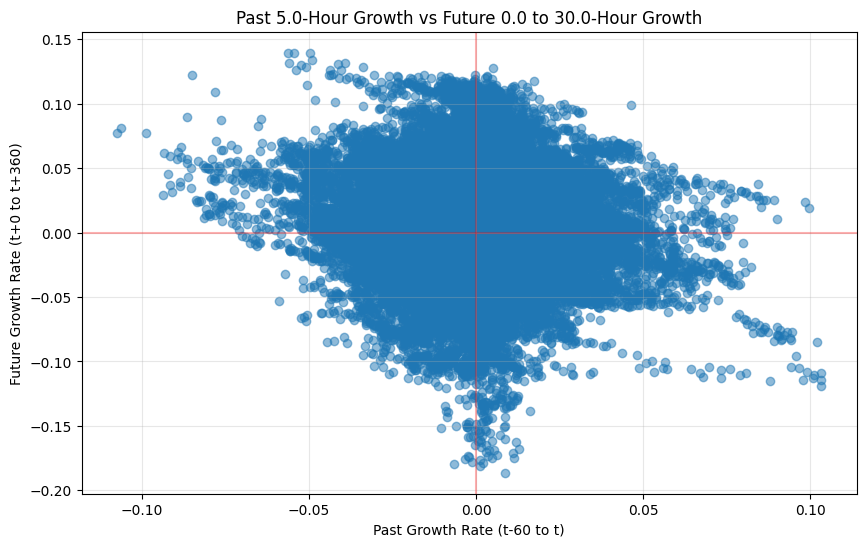


Correlation coefficient between past and future growth rates: -0.0426

Merged results example:
                            Close  past_growth_rate  future_growth_rate
Close Time                                                             
2024-01-01 05:04:59.999  42320.92         -0.001800            0.078480
2024-01-01 05:09:59.999  42339.99         -0.001650            0.077052
2024-01-01 05:14:59.999  42352.00         -0.003201            0.075746
2024-01-01 05:19:59.999  42356.00         -0.002422            0.075903
2024-01-01 05:24:59.999  42338.33         -0.003193            0.075669


In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# Calculate past and future growth rates with configurable parameters
def calculate_all_growth_rates(btc, past_window=60, future_start=150, future_end=210):
    """
    Calculate two growth rates for each row in the BTC dataframe:
    1. Past growth rate (t-past_window to t)
    2. Future growth rate (t+future_start to t+future_end)
    
    Parameters:
    -----------
    btc : pd.DataFrame
        DataFrame containing BTC price data with 'Close' column
    past_window : int
        Number of time steps to look back for past growth calculation
    future_start : int
        Starting point for future window (time steps after current point)
    future_end : int
        Ending point for future window (time steps after current point)
    
    Returns:
    --------
    tuple of pd.Series
        Two Series with the same index as the original dataframe
    """
    # Create empty Series with the same index as btc
    past_growth_series = pd.Series(index=btc.index, dtype=float)
    future_growth_series = pd.Series(index=btc.index, dtype=float)
    
    # Get Close column as numpy array for better performance
    close_values = btc['Close'].values
    
    # Calculate growth rates for all valid indices
    valid_range = range(past_window, len(btc) - future_end)
    
    print(f"Calculating growth rates with parameters: past_window={past_window}, future_start={future_start}, future_end={future_end}")
    for t in tqdm(valid_range):
        # Calculate past growth rate (t-past_window to t)
        past_growth = (close_values[t] - close_values[t-past_window]) / close_values[t-past_window]
        
        # Calculate future growth rate (t+future_start to t+future_end)
        future_growth = (close_values[t+future_end] - close_values[t+future_start]) / close_values[t+future_start]
        
        # Store at corresponding index position
        past_growth_series.iloc[t] = past_growth
        future_growth_series.iloc[t] = future_growth
    
    return past_growth_series, future_growth_series

# Set the parameters
past_window = 60     # 5 hours with 5-minute intervals
future_start = 0   # 12.5 hours ahead
future_end = 360     # 17.5 hours ahead

holding_period = future_end - future_start  # Holding period for future growth

# Apply function to calculate growth rates
past_growth, future_growth = calculate_all_growth_rates(btc, past_window, future_start, future_end)

# Print the first few valid values to verify
print("\nFirst few valid values of past growth rate:")
print(past_growth.dropna().head())

print("\nFirst few valid values of future growth rate:")
print(future_growth.dropna().head())

# Create scatter plot showing relationship between past and future growth rates
valid_data = pd.DataFrame({
    'past_growth': past_growth,
    'future_growth': future_growth
}).dropna()

# Time descriptions for plot labels
past_hours = past_window * 5 / 60  # Convert 5-minute intervals to hours
future_start_hours = future_start * 5 / 60
future_end_hours = future_end * 5 / 60

plt.figure(figsize=(10, 6))
plt.scatter(valid_data['past_growth'], valid_data['future_growth'], alpha=0.5)
plt.axhline(y=0, color='r', linestyle='-', alpha=0.3)
plt.axvline(x=0, color='r', linestyle='-', alpha=0.3)
plt.title(f'Past {past_hours:.1f}-Hour Growth vs Future {future_start_hours:.1f} to {future_end_hours:.1f}-Hour Growth')
plt.xlabel(f'Past Growth Rate (t-{past_window} to t)')
plt.ylabel(f'Future Growth Rate (t+{future_start} to t+{future_end})')
plt.grid(True, alpha=0.3)
plt.show()

# Calculate correlation coefficient
correlation = valid_data['past_growth'].corr(valid_data['future_growth'])
print(f"\nCorrelation coefficient between past and future growth rates: {correlation:.4f}")

# Save results
result_df = pd.DataFrame({
    'Close': btc['Close'],
    'past_growth_rate': past_growth,
    'future_growth_rate': future_growth
})

# Output a few examples for inspection
print("\nMerged results example:")
print(result_df.dropna().head())


Processing trades...


100%|██████████| 174972/174972 [00:00<00:00, 4636717.65it/s]


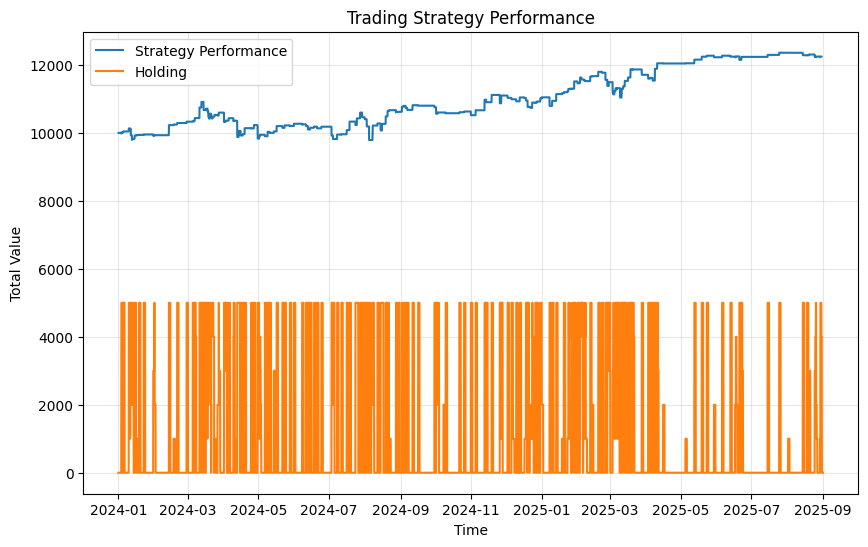

In [73]:
# 优化版的策略实现函数
def implement_strategy_optimized(btc, past_growth, future_growth, holding_period, threshold=0.01, initial_cap=10000):
    """
    Implement a simple trading strategy based on past and future growth rates - optimized version.

    Parameters:
    -----------
    btc : pd.DataFrame
        DataFrame containing BTC price data with 'Close' column
    past_growth : pd.Series
        Series containing past growth rates
    future_growth : pd.Series
        Series containing future growth rates
    holding_period : int
        Number of periods to hold a position
    threshold : float
        Growth rate threshold for making buy/sell decisions
    initial_cap : float
        Initial capital for the strategy

    Returns:
    --------
    tuple
        (performance_df, pnls, holding): DataFrames containing strategy performance
    """
    # Get valid indices
    valid_indices = range(past_window, len(btc) - future_end)
    total_length = len(valid_indices)
    
    # Pre-allocate arrays for better performance
    performance = np.zeros(total_length)
    pnls = []
    holding = np.zeros(len(btc))
    
    # Initialize capital
    capital = initial_cap
    
    # Create a mask for trade signals
    past_growth_values = past_growth.iloc[valid_indices].values
    future_growth_values = future_growth.iloc[valid_indices].values
    
    # Generate trade signals
    valid_mask = ~np.isnan(past_growth_values) & ~np.isnan(future_growth_values)
    trade_signals = (past_growth_values < threshold) & valid_mask
    
    # Process trades and update performance
    print("Processing trades...")
    for i, t in enumerate(tqdm(valid_indices)):
        if valid_mask[i]:
            if trade_signals[i] and holding[t] < 5000:
                # Calculate PnL
                pnl = (future_growth_values[i]-0.001) * 1000
                pnls.append(pnl / 1000)
                capital += pnl
                
                # Update holding period - use vectorized approach
                end_idx = min(t + holding_period, len(holding))
                holding[t:end_idx] += 1000
            
            performance[i] = capital
    
    # Create DataFrames for return values
    time_index = btc.index[valid_indices]
    performance_df = pd.DataFrame({
        'Total Value': performance
    }, index=time_index)
    
    holding_series = pd.Series(holding, index=btc.index)
    
    return performance_df, pnls, holding_series

# 运行优化后的策略
strategy_performance, pnls, holding = implement_strategy_optimized(
    btc, past_growth, future_growth, holding_period, threshold=-0.02, initial_cap=10000
)

# 绘制策略表现
plt.figure(figsize=(10, 6))
plt.plot(strategy_performance, label='Strategy Performance')
plt.plot(holding, label='Holding')
plt.title('Trading Strategy Performance')
plt.xlabel('Time')
plt.ylabel('Total Value')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [74]:

# 将 pnls 转换为 numpy 数组以便计算
import numpy as np
pnls_array = np.array(pnls)

# 计算基本统计指标
stats = {
    "总交易次数": len(pnls_array),
    "平均收益率": np.mean(pnls_array),
    "中位数收益率": np.median(pnls_array),
    "最大收益率": np.max(pnls_array),
    "最小收益率": np.min(pnls_array),
    "标准差": np.std(pnls_array),
    "正收益交易数": np.sum(pnls_array > 0),
    "负收益交易数": np.sum(pnls_array < 0),
    "胜率": np.mean(pnls_array > 0),
    "盈亏比": np.mean(pnls_array[pnls_array > 0]) / abs(np.mean(pnls_array[pnls_array < 0])) if np.any(pnls_array < 0) else float('inf'),
    "夏普比率": np.mean(pnls_array) / np.std(pnls_array) if np.std(pnls_array) > 0 else 0,
    "总收益率": np.sum(pnls_array)
}

# 打印统计指标
for key, value in stats.items():
    print(f"{key}: {value:.4f}" if isinstance(value, (float, np.float64)) else f"{key}: {value}")

总交易次数: 767
平均收益率: 0.0029
中位数收益率: 0.0045
最大收益率: 0.1186
最小收益率: -0.1031
标准差: 0.0311
正收益交易数: 445
负收益交易数: 322
胜率: 0.5802
盈亏比: 0.9283
夏普比率: 0.0940
总收益率: 2.2430


In [75]:
holding

Close Time
2024-01-01 00:04:59.999000    0.0
2024-01-01 00:09:59.999000    0.0
2024-01-01 00:14:59.999000    0.0
2024-01-01 00:19:59.999000    0.0
2024-01-01 00:24:59.999000    0.0
                             ... 
2025-08-31 23:39:59.999999    0.0
2025-08-31 23:44:59.999999    0.0
2025-08-31 23:49:59.999999    0.0
2025-08-31 23:54:59.999999    0.0
2025-08-31 23:59:59.999999    0.0
Length: 175392, dtype: float64